# Retrieving and Aggregating AORC Data for an Area
## NWM Projected data

**Authors:** 

<ul style="line-height:1.5;">
<li>Homa Salehabadi <a href="mailto:homa.salehabadi@usu.edu">(homa.salehabadi@usu.edu)</a></li>
<li>David Tarboton <a href="mailto:david.tarboton@usu.edu">(david.tarboton@usu.edu)</a></li>
<li>Ayman Nassar <a href="mailto:ayman.nassar@usu.edu">(ayman.nassar@usu.edu)</a></li>
<li>Anthony Castronova <a href="mailto:acastronova@cuahsi.org">(acastronova@cuahsi.org)</a></li>
<li>Pabitra Dash <a href="mailto:pabitra.dash@usu.edu">(pabitra.dash@usu.edu)</a></li>
</ul>

**Last Updated:** 7/22/2025

**Purpose:**

This notebook provides code examples for retrieving NOAA Analysis of Record for Calibration (AORC) data from Amazon Web Services (AWS). It is intended to make it easy for researchers to access data for a specific spatial domain specified by a shapefile. It also allows for data aggregation at time scales different from the underlying NOAA data.

**Audience:**

Researchers who are familiar with Jupyter Notebooks, basic Python and basic hydrologic data analysis.

**Description:**

This notebook takes as inputs a shapefile of a specific location, start and end dates for the desired period, a variable name, and a preferred time aggregation interval. It then retrieves data from Amazon Web Services, aggregates it over the specified time interval and individual shapes within the input shapefile, saves the data as a comma separated variable (CSV) file, and visualize the it. 

**Data Description:**

This notebook uses AORC data from the National Water Model (NWM) Retrospective archive, which includes input and output from multi-decade retrospective simulations. The data is available through AWS Open Data Registry (<https://registry.opendata.aws/nwm-archive/>). This notebook uses the Zarr format files of AORC version 1.1, located at `s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/forcing`. Zarr is a format for storage of chunked, compressed, N-dimensional arrays, designed to support storage using distributed systems such as cloud object stores (<https://zarr.dev/>).

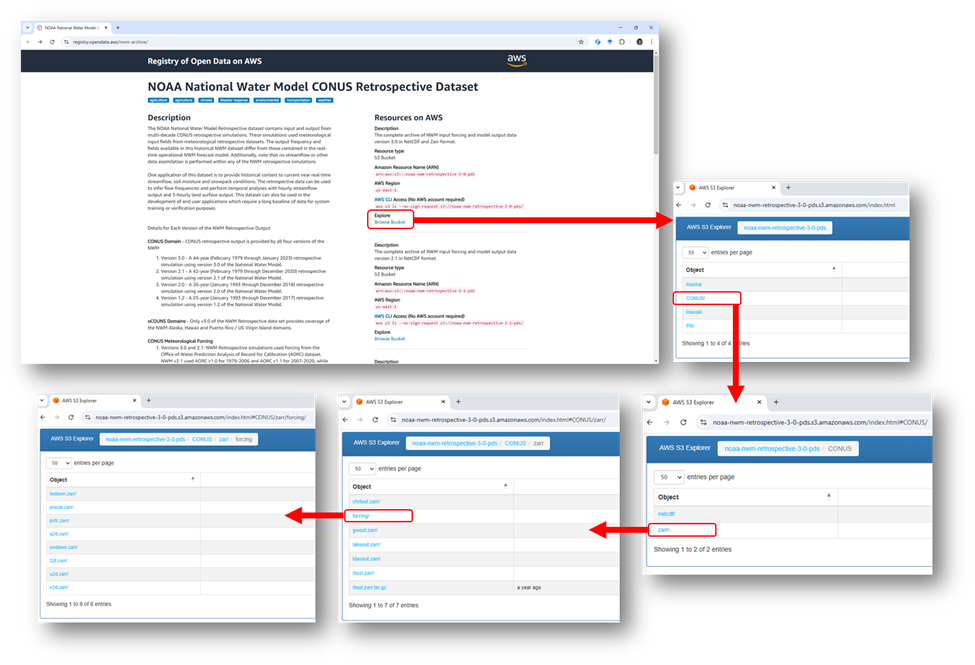

**Software Requirements:**

This notebook uses a number of Python libraries, which are imported in the first cell below. If any of these libraries are not installed, you may need to install them. If installing them results in problems due to package conflicts, we recommend setting up a Conda environment to run this notebook. The notebook [CondaEnvironmentSetup](./conda_env/CondaEnvironmentSetup.ipynb) has been provided to do this for you. Once you have set up the Conda environment, you will need to switch the kernel being used to execute this notebook to the new Conda environment: use *Python [cond env:.conda-aorc]* if this kernel is in the list, otherwise, use *Python3 (AORC)*.  


### 1. Import the Libraries

Import the libraries needed to run this notebook:

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box
from aorc_utils import load_dataset, get_aggregation_code, display_shapefile_map, da_animate
import pyproj
import warnings
from exactextract import exact_extract

### 2. Set Inputs

In the next cell, set values that specify which data to retrieve. Note that a shapefile holding Great Salt Lake subbasins has been provided with this resource. Add your own shapefile and provide the path to its location to retrieve data for a different location.

Variables available:

|Variable Name| Long Name                                   | Standard Name                        | Units   |
|-------------|---------------------------------------------|--------------------------------------|---------|
| RAINRATE    | Surface Precipitation Rate                  | precipitation_flux                   | mm s⁻¹  |
| T2D         | 2-m Air Temperature                         | air_temperature                      | K       |
| Q2D         | 2-m Specific Humidity                       | surface_specific_humidity            | kg kg⁻¹ |
| LWDOWN      | Surface downward long-wave radiation flux   | surface_downward_longwave_flux       | W m⁻²   |
| SWDOWN      | Surface downward short-wave radiation flux  | surface_downward_shortwave_flux      | W m⁻²   |
| PSFC        | Surface Pressure                            | air_pressure                         | Pa      |
| U2D         | 10-m U-component of wind                    | x_wind                               | m s⁻¹   |
| V2D         | 10-m V-component of wind                    | y_wind                               | m s⁻¹   |

Enter the Variable Name for the variable to retrieve in the cell below.

In [ ]:
# Start date - In Year-Month-Day format the earliest start date can be '1979-02-01'
start_datetime = '2020-01-01'

# End date - In Year-Month-Day format the latest end date can be '2023-01-31'
end_datetime = '2020-12-31'

# File path to the shape file to used as an input
shapefile_path = "./GSLSubbasins/GSLSubbasins.shp"

# Basin name (this will be used on the maps and plots)
basin_name = "Great Salt Lake Basin"

# User-defined inputs - this can be any variable name as listed above
variable_name = 'RAINRATE'

# User-defined aggregation interval - valid values are 'hour','day','month','year'
agg_interval = 'month'

### 3. Read Shapefile and Display Map

Read the shapefile of the defined basin using the GeoPandas library. 

In [ ]:
# Read the shapefile using GeoPandas
gdf = gpd.read_file(shapefile_path)

Optional: Render a simple map to show the location of the basin. This is done using the `display_shapefile_map` function defined in aorc_utils.py to first plot the input basin defined above using the GeoPandas library, and then adding a basemap using the Contextily library. This is not needed for extraction of the data at the input location but serves as a check on the input location.

In [ ]:
# Display shapefile and map (optional)
display_shapefile_map(gdf, basin_name)

### 4. Virtually Load the Data Array 

The AORC dataset is very large, and impractical to download in its entirety. The `Xarray` library is used to reference and "lazily" retrieve only the parts that are needed. This works by reading a minimal set of metadata that will enable us to define analysis operations. The AORC dataset that we'll be loading is in the Zarr format and is hosted on Amazon S3: `s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/forcing`. The following code will load these data into an `Xarray` DataSet which we can then use to subset and aggregate the data.

In [ ]:
# Base URL to the NWM forcing data
base_url = f's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/forcing'

# URL to the variable of interest
if variable_name == 'RAINRATE' : variable_code = "precip"
else: variable_code = variable_name.lower()
url = f's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/forcing/{variable_code}.zarr'
print(f'URL: {url}')

# Load the data
ds = load_dataset(url)
ds

Print information on the dataset to show its AORC name, units and geographic coordinate system information.

In [ ]:
# Print the selected variable and its units
variable_long_name = ds[variable_name].attrs.get('long_name')
print(f"Data Variable: {list(ds.data_vars)[0]} ({variable_long_name})")
print(f"{list(ds.data_vars)[0]} units: {ds[list(ds.data_vars)[0]].attrs.get('units', 'No units specified')}\n")

# Print selected variable dataset information
print(ds)

print('\n')
print(f'Additional items associated with the {list(ds.data_vars)[0]} variable')
for k, v in ds[list(ds.data_vars)[0]].attrs.items():
    print(f'\n{k} -> {v}')

### 5. Check Coordinate Reference System (CRS)

Use the following cell to check the Coordinate Reference System (CRS) of the shapefile and reproject it if the shapefile CRS does not match the dataset CRS. This ensures that spatial data extractions, calculations, and visualizations are correctly aligned on the same coordinate system. 
The AORC data coordinate system is a Lambert Conformal Conic projection used by the National Water Model. Curious users could examine ds.crs.esri_pe_string to see details.

In [ ]:
# Dataset CRS
crs_dataset = pyproj.CRS(ds.crs.esri_pe_string)
print(f'\033[1mDataset CRS ---> \033[0m {crs_dataset}')
print(f'\033[1mOriginal Shapefile CRS ---> \033[0m {gdf.crs}')

# Reproject shapefile if needed
if gdf.crs != crs_dataset:
    gdf = gdf.to_crs(crs_dataset)
print(f'\033[1mReprojected Shapefile CRS ---> \033[0m {gdf.crs}')

In [ ]:
# Compute area in the projected CRS
gdf['Projected_Area_km2'] = gdf['geometry'].area/ 10**6  # Area in square kilometers
total_area = gdf['Projected_Area_km2'].sum()
print(f'Total {basin_name} Area is {total_area} km2')
gdf

### 6. Subset and Aggregate the Data Across Time and Space

#### 6.1. Temporal Aggregation

In the following cell, we retrieve data for the defined area and aggregates it in time to the user-defined time scale (the input AORC data has an hourly time step). The output is a DataArray called `da_over_area`, which contains the temporally aggregated subset over the entire area.

In [ ]:
## Aggregation time interval
agg_code = get_aggregation_code(agg_interval)

# Bounding box extraction (for efficiency, we first subset the dataset for the bounding box, then clip the data for the basin.) 
bounding_box = box(*gdf.total_bounds)
x_min, y_min, x_max, y_max = bounding_box.bounds
ds_bbox = ds[variable_name].sel(y=slice(y_min, y_max), x=slice(x_min, x_max))

if variable_name == 'RAINRATE':
    ds_bbox_TimeAgg = ds_bbox.loc[dict(time=slice(start_datetime, end_datetime))].resample(time=agg_code).sum() * 3600
    units = f"mm/{agg_interval}"

else:
    ds_bbox_TimeAgg = ds_bbox.loc[dict(time=slice(start_datetime, end_datetime))].resample(time=agg_code).mean()
    units = ds[variable_name].attrs.get('units', 'No units specified')

# Ensure dataset has CRS for exact_extract
ds_bbox_TimeAgg.rio.write_crs(gdf.crs, inplace=True)

# Clip data for the basin
geom_union = gdf.unary_union
da_over_area = ds_bbox_TimeAgg.rio.clip([geom_union], gdf.crs, all_touched=True)
# Note: The `all_touched` parameter controls whether to include all cells that are even partially touched by the vector (all_touched = True) or only those whose 
# center falls inside the vector (all_touched = False). Set all_touched = True to ensure that every cell that intersects the vector, even if only slightly, is 
# included. We will then use exactextract library to extract the exact zonal statistics. 

da_over_area

#### 6.2. Zonal Aggregation

Use `exactextract` for zonal aggregation. `exactextract` is a library for extracting and summarizing the values in the portion of a raster dataset that is covered by a polygon, often referred to as zonal statistics. More information can be found at <https://isciences.github.io/exactextract/index.html>.

The following cell computes the mean for each subbasin separately, as well as for the entire basin. The output is a DataFrame called `df_mean_over_area`, with time in the first column followed by the values for the variable of interest for each subbasin and the entire basin.

In [ ]:
%%time

# Suppress a warning for potential future changes in GDAL (Geospatial Data Abstraction Library).
warnings.filterwarnings("ignore") 

# Compute mean for each subbasins using exactextract
df_zonal_agg_subbasins = exact_extract(da_over_area, gdf, "mean", include_cols=["name"], output='pandas')

# The following lines will organaize the output dataframe to make it easier to analyze and plot,
# and also calculate the mean for the entire basin based on the means of the subbasins.

df_mean_over_area = df_zonal_agg_subbasins.copy()

# Format time labels
time_coords = pd.to_datetime(da_over_area['time'].values)
formatted_dates = time_coords.strftime(
    '%Y-%m-%d %H:%M:%S' if agg_interval == 'hour' else  
    '%Y-%m-%d' if agg_interval == 'day' else
    '%Y-%m' if agg_interval == 'month' else
    '%Y'
)

# Rename the columns to match time periods
df_mean_over_area.columns = ['subbasin'] + list(formatted_dates)  

# Set "subbasin" as index for easier plotting
df_mean_over_area.set_index('subbasin', inplace=True)

# Transpose data for plotting (time as index, subbasins as columns)
df_mean_over_area = df_mean_over_area.T 

# Calculate mean values for the entire basin based on subbasins. This will proceed only if there are more than one subbasin. 
if len(gdf) > 1: # Check if there are more than one subbasin in the gdf
    subbasin_area = gdf['Projected_Area_km2']
    # Multiply the values by the respective subbasin areas
    weighted_values = df_mean_over_area.multiply(subbasin_area.values, axis=1)
    # Calculate the weighted mean for the entire basin
    weighted_mean_entire_basin = weighted_values.sum(axis=1) / total_area
    # Add the "Entire Basin" column
    df_mean_over_area['Entire Basin'] = weighted_mean_entire_basin

# Print the units
print(f"units --> {units}")
# Display the result
df_mean_over_area

### 7. Save the Data as a CSV File

In [ ]:
# Specify the file path where you want to save the CSV file
file_path = f"AORC_NWMProj_ZoneRetrieval_{variable_name}.csv"

# Save the DataFrame to a CSV file
df_mean_over_area.to_csv(file_path, index=True)  

### 8. Plot the Data (Optional)

Use the following cell to plot time series of temporally and spatially aggregated data over the subbasins and the entire basin. 

In [ ]:
# Plot time series for each subbasin
plt.figure(figsize=(12, 6))

for subbasin in df_mean_over_area.columns:  
    plt.plot(df_mean_over_area.index, df_mean_over_area[subbasin], label=subbasin, linewidth=1, marker='o', markersize=4)

plt.title(f'{variable_name}, {variable_long_name} ({formatted_dates[0]} - {formatted_dates[-1]})', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(f'{agg_interval.capitalize()}', fontsize=14)
plt.ylabel(f'{variable_name} ({units})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.tight_layout()

# Save and display the plot
plt.savefig(f'AORC_NWMProj_ZoneRetrieval_{variable_name}.png', dpi=300)
plt.show()

Use the following cell to visualize temporally aggregated subset over the entire area as an animated plot: 

In [ ]:
da_animate(da_over_area, gdf, variable_name, units, agg_interval)